# Benchmark 03 — CNN poco profunda (clasificación, MNIST)

**Universidad Central de Venezuela**

Facultad de Ciencias | Escuela de Computación



**Estudiante:** Rafael Eduardo Contreras

**Cédula / ID:** 30391915

**Tutor:** Eugenio Scalise

---

## Introducción

Este notebook compara el rendimiento de inferencia cifrada del SDK desarrollado
con otras bibliotecas similares. Las bibliotecas evaluadas en este notebook son:

- **Nuestra SDK**: CKKS sobre GPU, basada en HEonGPU
- **Concrete-ML**: TFHE sobre GPU, compilador de Zama

Para cada biblioteca se mide:

- **Latencia por muestra**: segundos de inferencia cifrada extremo a extremo.
- **Exactitud (accuracy)**: comparando contra la inferencia en claro como referencia.
- **Pico de VRAM y RAM**: memoria de GPU y de proceso durante la inferencia.

Como punto de comparación adicional se incluye la inferencia con PyTorch, que sirve como cota
inferior de tiempo y cota superior de exactitud para todas las versiones
cifradas.

## Instalación de dependencias

Instalaremos paquetes comunes en el desarrollo, entrenamiento y evaluacion de redes neuronales, como numpy
pytorch y matplotlib. Luego se instalara fhe-sdk, esta es la libreria desarrollada para realizar inferencia cifrada.

Finalmente se instalara concrete-ml y sus paquetes compatibles con el gpu usado.

> **Nota CUDA:** `fhe-sdk` compila CUDA al instalarse y necesita CUDA Toolkit 12.8 + GPU
>
> Para Concrete-ML, `concrete-python` se reinstala desde el índice GPU de
> Zama (`pypi.zama.ai/gpu`) — el wheel de PyPI es sólo CPU.

In [7]:
!pip install -q numpy pandas matplotlib scikit-learn psutil pynvml datasets


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
!BUILD_JOBS=$(nproc) pip install fhe-sdk==0.1.3

  Using cached fhe_sdk-0.1.3.tar.gz (1.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fhe-sdk: filename=fhe_sdk-0.1.3-cp311-cp311-linux_x86_64.whl size=23358739 sha256=93c68a62620a42ca32334d23e9fd97b77dc418d24baebc204ff2021a4d2a75ac
  Stored in directory: /root/.cache/pip/wheels/c4/4c/7a/378efb3d4c9cd6285512a6eebf741251d9a923c2468fcf58d5
Successfully built fhe-sdk

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
!pip uninstall -y concrete-python
!pip install concrete-ml
!pip install --no-deps --extra-index-url https://pypi.zama.ai/gpu --trusted-host pypi.zama.ai 'concrete-python==2024.12.19'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.6/626.6 kB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 MB 127.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 MB 130.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 203.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 73.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.1/678.1 kB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 256.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 30.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 MB 81.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 120.6 MB/s eta 0:00:000

La siguiente celda sirve para evaluar que todas las herramientas instaladas tengan acceso al GPU. Es necesario debido a que durante una mala instalacion de concrete-ml pueden existir errores de compatibilidad que no permiten que use el GPU, aveces estos errores se propagan a pytorch, por eso tambien evaluamos que el mismo tenga acceso al gpu.

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())     # True

import concrete.compiler
print(concrete.compiler.check_gpu_enabled())     # True
print(concrete.compiler.check_gpu_available())   # True

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


2.3.1+cu121
12.1
True
True
True


In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no disponible: este benchmark requiere GPU (SDK y Concrete-ML).")
DEVICE = torch.device("cuda")
print(f"PyTorch device = {DEVICE}")

PyTorch device = cuda


In [ ]:
La siguiente celda define una funcion para liberar el gpu en pytorch. Ademas definimos una clase que se encarga de medir lo siguiente:

- tiempo por inferencia
- memoria usada por iteracion
- vram usada por iteracion

In [3]:
import threading
import time
import gc
import psutil
import pynvml

# TODO: agregar una funcion "empty" al sdk e investigar lo mismo para concrete-ml
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


class Measure:
    def __init__(self):
        self._proc = psutil.Process()

    def __enter__(self):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, *_):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self.elapsed_s   = time.perf_counter() - self._t0
        self.peak_rss_mb  = self._proc.memory_info().rss / 1024**2
        self.peak_vram_mb = pynvml.nvmlDeviceGetMemoryInfo(_NVML).used / 1024**2
        self.abs_peak_vram_mb = self.peak_vram_mb  # alias for existing code
        return False

## Red y entrenamiento

### Datos: MNIST

70 000 imágenes 28×28 en escala de grises (dígitos 0–9). Se carga con
`sklearn.datasets.fetch_openml("mnist_784")` para evitar dependencias
adicionales. Los píxeles se normalizan a [0, 1] y luego se estandarizan
con las estadísticas del set de entrenamiento.

In [4]:
!python -c "import torch; print(torch.__version__)" 

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2.3.1+cu121


In [5]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple
from datasets import load_dataset
from sklearn.model_selection import train_test_split

SEED = 30391915


@dataclass
class Dataset:
    x_train: np.ndarray
    x_test: np.ndarray
    y_train: np.ndarray
    y_test: np.ndarray
    image_shape: Tuple[int, int] = (28, 28)
    n_classes: int = 10

    @property
    def n_features(self) -> int:
        return self.x_train.shape[1]


def load_mnist(test_size: float = 0.2) -> Dataset:
    ds = load_dataset("ylecun/mnist")
    train_imgs = np.stack([np.asarray(im) for im in ds["train"]["image"]])
    test_imgs  = np.stack([np.asarray(im) for im in ds["test"]["image"]])
    x = np.concatenate([train_imgs, test_imgs]).reshape(-1, 784).astype(np.float32) / 255.0
    y = np.concatenate([ds["train"]["label"], ds["test"]["label"]]).astype(np.int64)
    x_tr, x_te, y_tr, y_te = train_test_split(
        x, y, test_size=test_size, random_state=SEED, stratify=y,
    )
    mean, std = float(x_tr.mean()), float(x_tr.std())
    x_tr = (x_tr - mean) / std
    x_te = (x_te - mean) / std
    return Dataset(x_tr, x_te, y_tr, y_te)
    
data = load_mnist()
print(f"train: {data.x_train.shape}, test: {data.x_test.shape}")

train: (56000, 784), test: (14000, 784)


### Arquitectura y entrenamiento

`Conv2d(1 → 4, kernel 7, stride 5) → ReLU → Linear(100 → 10)`

In [6]:
from torch import nn

def build_network():
    return nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=4, kernel_size=7, stride=5),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(4 * 5 * 5, 10),
    )

In [7]:
from torch import nn

def train_classification(model, data, epochs=8, batch_size=256, lr=1e-3):
    h, w = data.image_shape
    x = torch.tensor(data.x_train, dtype=torch.float32, device=DEVICE).reshape(-1, 1, h, w)
    y = torch.tensor(data.y_train, dtype=torch.long, device=DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    n = len(x)
    model.train()
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss_fn(model(x[idx]), y[idx]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
    model.eval()
    return model


torch_model = build_network().to(DEVICE)
train_classification(torch_model, data)
print(torch_model)

Sequential(
  (0): Conv2d(1, 4, kernel_size=(7, 7), stride=(5, 5))
  (1): ReLU()
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=100, out_features=10, bias=True)
)


## Inferencia cifrada

### Nuestra SDK

Implementación del esquema RNS-CKKS construida sobre HEonGPU, con
todas las operaciones (multiplicación, rotación, rescale, bootstrapping)
ejecutadas en la GPU vía CUDA.

In [8]:
from api import FHEContext
from api.layers.linear import Linear
from api.layers.conv2d import Conv2D
from api.functions.relu import ReLU
from api.sequential import Sequential
from core.enums import SecurityLevel

# 128 bits de seguridad
# para esta profundidad el chain de bootstrapping requiere n = 65536, lo que
# implica un set de claves Galois de ~24 GB en VRAM

POLY_DEGREE   = 65_536
COEFF_MODULUS = [60] + [53] * 28 + [60]   
SCALE         = 2**53                    
SECURITY      = SecurityLevel.SEC128

# configuracion rapida e insegura, solo para development
# POLY_DEGREE   = 8_192
# COEFF_MODULUS = [60] + [50] * 28 + [60]
# SCALE         = 2**50
# SECURITY      = SecurityLevel.NONE

# esto define que tan precisa sera la aproximacion de ReLU. 
# El primer argumento define que tantos polinomios seran compuestos, el segundo define su grado
RELU_DEGREES = (5,) * 9
free_gpu()

In [9]:
def to_sdk_model(torch_model, image_shape):
    cpu_model = torch_model.cpu()
    h, w = image_shape
    layers = []
    for m in cpu_model:
        if isinstance(m, torch.nn.Conv2d):
            stride = m.stride[0] if isinstance(m.stride, tuple) else m.stride
            layers.append(Conv2D(
                in_channels=m.in_channels, out_channels=m.out_channels,
                kernel_size=m.kernel_size, input_shape=(h, w),
                weight=m.weight.detach().numpy(),
                bias=m.bias.detach().numpy(),
                stride=stride,
            ))
            kh, kw = m.kernel_size
            h = (h - kh) // stride + 1
            w = (w - kw) // stride + 1
        elif isinstance(m, torch.nn.Linear):
            layers.append(Linear(
                m.in_features, m.out_features,
                m.weight.detach().numpy(), m.bias.detach().numpy(),
            ))
        elif isinstance(m, torch.nn.Flatten):
            continue
        else:
            layers.append(ReLU(degrees=RELU_DEGREES))
    return Sequential(layers)

### Concrete-ML

Compilador FHE de Zama basado en TFHE. A diferencia de CKKS, TFHE
hace **bootstrapping programable** por operación, lo que le permite
ejecutar ReLU real (no aproximada) y redes de profundidad arbitraria.
Toda la aritmética es entera, así que el modelo PyTorch se cuantiza antes de
compilarse al circuito TFHE.

In [10]:
from concrete.ml.torch.compile import compile_torch_model

# N_BITS=parametro de cuantizacion.
# N_CALIB=muestras del set de entrenamiento usadas para fijar la cuantización

N_BITS     = 6
N_CALIB    = 200

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no disponible: Concrete-ML requiere GPU en este benchmark.")

import concrete.compiler
if not concrete.compiler.check_gpu_enabled():
    raise RuntimeError(
        "Build de concrete-python sin soporte GPU. "
        "Reinstala desde https://pypi.zama.ai/gpu y reinicia el kernel."
    )
if not concrete.compiler.check_gpu_available():
    raise RuntimeError("Concrete-ML no detecta la GPU (check_gpu_available()=False).")

CML_DEVICE = "cuda"
print(f"Concrete-ML device = {CML_DEVICE}")

h, w = data.image_shape
torch_cpu = torch_model.cpu()
calib = torch.tensor(data.x_train[:N_CALIB], dtype=torch.float32).reshape(-1, 1, h, w)

Concrete-ML device = cuda


## Resultados

Cada biblioteca corre el mismo subconjunto de prueba con los mismos pesos
plaintext. Las métricas reportadas son:

- **Latencia media por muestra** — incluye cifrado, inferencia y descifrado.
- **Exactitud** — calidad de la predicción cifrada. La columna
  *baseline* corresponde a la inferencia en plano.
- **VRAM (MB)** — memoria GPU consumida.
- **RAM (MB)** — Ram consumida.

> Para Concrete-ML, la latencia y la memoria se miden con cifrado real
> (`fhe="execute"`, 1 muestra) y la precisión se calcula con simulación
> (`fhe="simulate"`, N muestras). Ambos modos ejecutan el **mismo circuito
> cuantizado** — la simulación produce salidas numéricamente equivalentes
> sin pagar el coste FHE, lo que permite estimar precisión sobre muestras
> suficientes en segundos en lugar de horas.

In [19]:
N_TEST = 5
x_test = data.x_test[:N_TEST].astype(np.float32)
y_test = data.y_test[:N_TEST]
h, w = data.image_shape
free_gpu()

torch_model.to(DEVICE).eval()
with torch.no_grad(), Measure() as m_plain:
    x_gpu = torch.tensor(x_test, device=DEVICE).reshape(-1, 1, h, w)
    plain_logits_t = torch_model(x_gpu)
    plain_pred = plain_logits_t.cpu().numpy().argmax(axis=1)
plain_latency = m_plain.elapsed_s / N_TEST

Para concrete-ml dividimos la medicion en dos partes. Debido a que el tiempo de inferencia por muestra es muy largo.
- fhe="execute": cifrado real, mide latencia + memoria (incluyendo compile)
- fhe="simulate": circuito cuantizado evaluado, sirve para medir R² sobre muchas muestras. Esto debido a que la inferencia toma demasiado tiempo

In [20]:
free_gpu()   

N_EXECUTE  = 1    
N_SIMULATE = 50    

x_exec = x_test[:N_EXECUTE]
with Measure() as m_cml:
    torch_cpu = torch_model.cpu()
    cml_model = compile_torch_model(torch_cpu, torch_inputset=calib, n_bits=N_BITS, device=CML_DEVICE)

    for i, x in enumerate(x_exec):
        print(f"[concrete-ml execute {i+1}/{N_EXECUTE}]", flush=True)
        img = x.reshape(1, 1, h, w)
        _ = cml_model.forward(img, fhe="execute")
cml_latency = m_cml.elapsed_s / N_EXECUTE

print(f"[concrete-ml simulate x{N_SIMULATE}]", flush=True)
x_sim = data.x_test[:N_SIMULATE].astype(np.float32)
y_test_sim = data.y_test[:N_SIMULATE]
cml_pred = np.empty(N_SIMULATE, dtype=int)
for i, x in enumerate(x_sim):
    img = x.reshape(1, 1, h, w)
    logits = np.asarray(cml_model.forward(img, fhe="simulate")).reshape(-1)[: data.n_classes]
    cml_pred[i] = int(np.argmax(logits))

[concrete-ml execute 1/1]
[concrete-ml simulate x50]


In [21]:
# inferencia cifrada SDK.
free_gpu()
ctx = (FHEContext()
    .set_poly_modulus_degree(POLY_DEGREE)
    .set_coeff_modulus_bit_sizes(COEFF_MODULUS)
    .set_scale(SCALE)
    .set_security_level(SECURITY)
    .set_galois_key_storage(on_host=True)
    .set_bootstrapping_params(3,3,11)
    .build())

sdk_model = to_sdk_model(torch_model, data.image_shape)
sdk_model.compile(ctx, calibration_data=data.x_train)
print(f"profundidad multiplicativa: "
      f"{sum(l.mult_depth() for l in sdk_model._layers)}")

sdk_pred = np.empty(N_TEST, dtype=int)
with Measure() as m_sdk:
    for i, x in enumerate(x_test):
        print(f"[SDK {i+1}/{N_TEST}]", flush=True)
        img = x.reshape(h, w)
        logits = sdk_model(sdk_model.input(ctx, img.tolist())).decrypt()[: data.n_classes]
        sdk_pred[i] = int(np.argmax(logits))
sdk_latency = m_sdk.elapsed_s / N_TEST

profundidad multiplicativa: 39
[SDK 1/5]
[SDK 2/5]
[SDK 3/5]
[SDK 4/5]
[SDK 5/5]


In [22]:
import pandas as pd

def acc(pred, y): return (pred == y).mean()

results = pd.DataFrame([
    {"backend": f"plaintext (PyTorch {DEVICE.type.upper()})",
     "latency_s": plain_latency, "exactitud": acc(plain_pred, y_test),
     "VRAM_MB": m_plain.peak_vram_mb, "RAM_MB": m_plain.peak_rss_mb,
     "muestras": int(N_TEST), "seguridad": "no aplica"},
    {"backend": "SDK propia (CKKS, GPU)", "latency_s": sdk_latency,
     "exactitud": acc(sdk_pred, y_test),
     "VRAM_MB": m_sdk.peak_vram_mb, "RAM_MB": m_sdk.peak_rss_mb,
     "muestras": int(N_TEST), "seguridad": str(SECURITY).split('.')[-1]},
    {"backend": f"Concrete-ML (TFHE, {CML_DEVICE.upper()})",
     "latency_s": cml_latency, "exactitud": acc(cml_pred, y_test_sim),
     "VRAM_MB": m_cml.peak_vram_mb, "RAM_MB": m_cml.peak_rss_mb,
     "muestras": f"{N_EXECUTE} (lat) / {N_SIMULATE} (acc)", "seguridad": "SEC128"},
])
results

,backend,latency_s,exactitud,VRAM_MB,RAM_MB,muestras,seguridad
0,plaintext (PyTorch CUDA),0.000652,1.00,22320.75,24535.710938,5,no aplica
1,"SDK propia (CKKS, GPU)",25.059382,0.60,22320.75,24702.085938,5,SEC128
2,"Concrete-ML (TFHE, CUDA)",607.513646,0.92,22320.75,25828.468750,1 (lat) / 50 (acc),SEC128


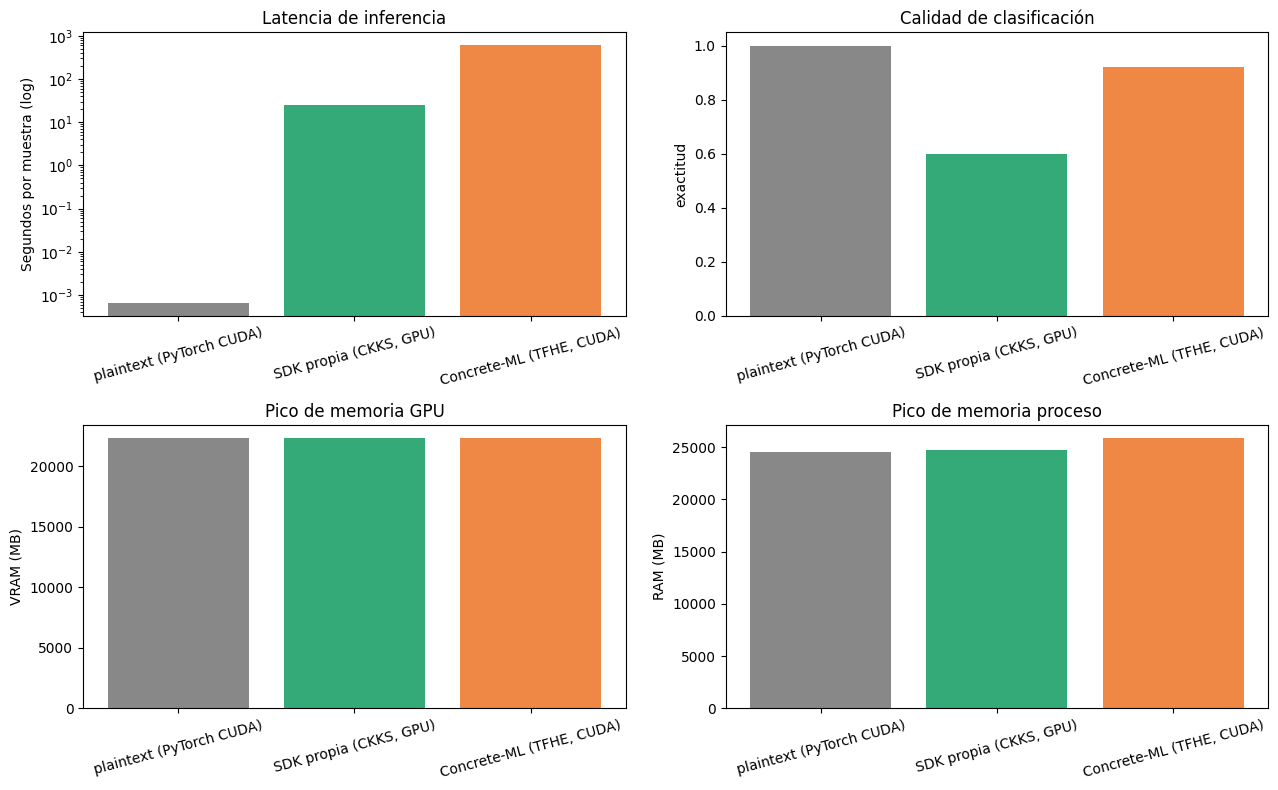

In [23]:
import matplotlib.pyplot as plt

palette = ["#888", "#3a7", "#e84", "#39c"]
colors = palette[: len(results)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].bar(results["backend"], results["latency_s"], color=colors)
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel("Segundos por muestra (log)")
axes[0, 0].set_title("Latencia de inferencia")
axes[0, 0].tick_params(axis="x", rotation=15)

axes[0, 1].bar(results["backend"], results["exactitud"], color=colors)
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].set_ylabel("exactitud")
axes[0, 1].set_title("Calidad de clasificación")
axes[0, 1].tick_params(axis="x", rotation=15)

axes[1, 0].bar(results["backend"], results["VRAM_MB"], color=colors)
axes[1, 0].set_ylabel("VRAM (MB)")
axes[1, 0].set_title("Pico de memoria GPU")
axes[1, 0].tick_params(axis="x", rotation=15)

axes[1, 1].bar(results["backend"], results["RAM_MB"], color=colors)
axes[1, 1].set_ylabel("RAM (MB)")
axes[1, 1].set_title("Pico de memoria proceso")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [24]:
# guarda la tabla de resultados a disco para post-procesamiento.
csv_path = "results_3.csv"
results.to_csv(csv_path, index=False)
print(f"resultados guardados en {csv_path}")

resultados guardados en results_3.csv


### Conclusiones

La velocidad de la libreria desarrollada es ordenes de magnitud mas rapida que concrete-ml. La precision es menor *con los parametros seleccionados*. Otros metaparametros dan resultados peores que concrete-ml. Es necesario desarrollar un algoritmo que seleccione los parametros optimos dada una red. Parece que con redes mas cortas concrete-ml tiene mejor desempeno a nivel de precision